In [ ]:

!pip install -q torch torchvision matplotlib numpy

Device: cpu


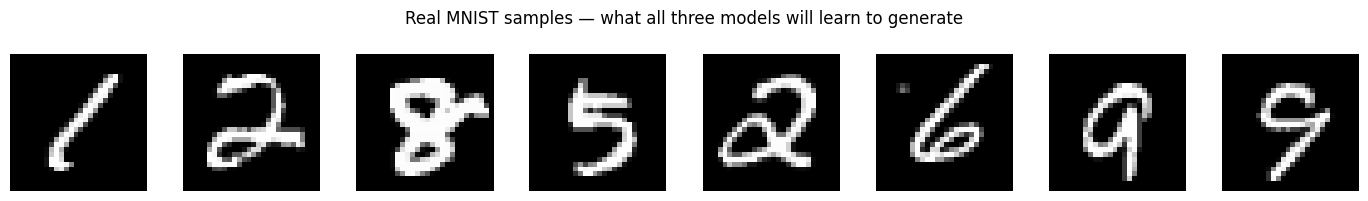

Image shape: torch.Size([1, 28, 28])  |  Pixel range: [-1.0, 1.0]


In [ ]:
# !pip install -q torch torchvision matplotlib numpy

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Shared dataset: MNIST digits — used across all three paradigms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))   # scale to [-1, 1]
])
mnist = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
loader = torch.utils.data.DataLoader(mnist, batch_size=128, shuffle=True)

# Display a sample
real_batch, _ = next(iter(loader))
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i, ax in enumerate(axes):
    ax.imshow(real_batch[i].squeeze(), cmap='gray')
    ax.axis('off')
plt.suptitle("Real MNIST samples — what all three models will learn to generate")
plt.tight_layout()
plt.show()
print(f"Image shape: {real_batch[0].shape}  |  Pixel range: [{real_batch.min():.1f}, {real_batch.max():.1f}]")

In [ ]:
# ============================================================
# GAN architecture
# Generator:     noise z → fake image
# Discriminator: image → real/fake probability
# Training:      adversarial — each tries to beat the other
# ============================================================

In [ ]:
LATENT_DIM = 64
IMAGE_DIM = 784   # 28×28 flattened

class Generator(nn.Module):
  def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(LATENT_DIM, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 512),        nn.LeakyReLU(0.2),
            nn.Linear(512, IMAGE_DIM),  nn.Tanh()  # output in [-1,1]
        )
  def forward(self, z): return self.net(z)

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(IMAGE_DIM, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, 256),       nn.LeakyReLU(0.2),
            nn.Linear(256, 1),         nn.Sigmoid()   # real probability
        )
    def forward(self, x): return self.net(x)

In [ ]:
G = Generator().to(device)
D = Discriminator().to(device)

In [ ]:
print("Generator:")
print(G)
print(f"\nGenerator parameters:     {sum(p.numel() for p in G.parameters()):,}")
print(f"Discriminator parameters: {sum(p.numel() for p in D.parameters()):,}")

Generator:
Generator(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=512, out_features=784, bias=True)
    (5): Tanh()
  )
)

Generator parameters:     550,416
Discriminator parameters: 533,505


In [ ]:
opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

criterion = nn.BCELoss()

G_losses, D_losses = [], []
EPOCHS = 10

  Epoch  1/10  G_loss=1.344  D_loss=0.918
  Epoch  2/10  G_loss=2.079  D_loss=0.753
  Epoch  3/10  G_loss=2.550  D_loss=0.626
  Epoch  4/10  G_loss=2.414  D_loss=0.613
  Epoch  5/10  G_loss=2.766  D_loss=0.553
  Epoch  6/10  G_loss=2.652  D_loss=0.622
  Epoch  7/10  G_loss=2.783  D_loss=0.535
  Epoch  8/10  G_loss=2.997  D_loss=0.505
  Epoch  9/10  G_loss=2.792  D_loss=0.558
  Epoch 10/10  G_loss=2.665  D_loss=0.586


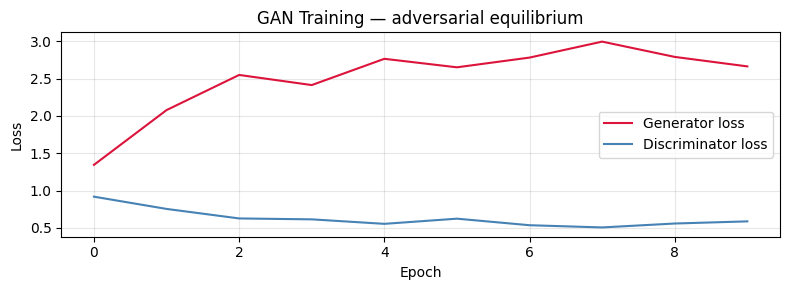

In [ ]:
for epoch in range(EPOCHS):
    g_loss_epoch, d_loss_epoch = 0.0, 0.0
    for real_imgs, _ in loader:
        real_imgs = real_imgs.view(-1, IMAGE_DIM).to(device)
        m = real_imgs.size(0)

        # --- Train Discriminator ---
        opt_D.zero_grad()
        real_labels = torch.ones(m, 1).to(device)
        fake_labels = torch.zeros(m, 1).to(device)
        d_real = criterion(D(real_imgs), real_labels)

        z = torch.randn(m, LATENT_DIM).to(device)
        fake_imgs = G(z).detach()   # detach: don't update G here
        d_fake = criterion(D(fake_imgs), fake_labels)

        d_loss = d_real + d_fake
        d_loss.backward()
        opt_D.step()

        # --- Train Generator ---
        opt_G.zero_grad()
        z = torch.randn(m, LATENT_DIM).to(device)
        g_loss = criterion(D(G(z)), real_labels)  # G wants D to say "real"
        g_loss.backward()
        opt_G.step()

        g_loss_epoch += g_loss.item()
        d_loss_epoch += d_loss.item()

    G_losses.append(g_loss_epoch / len(loader))
    D_losses.append(d_loss_epoch / len(loader))
    print(f"  Epoch {epoch+1:>2}/{EPOCHS}  G_loss={G_losses[-1]:.3f}  D_loss={D_losses[-1]:.3f}")

# Loss curve
plt.figure(figsize=(8, 3))
plt.plot(G_losses, label='Generator loss',     color='crimson')
plt.plot(D_losses, label='Discriminator loss', color='steelblue')
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(alpha=0.3)
plt.title("GAN Training — adversarial equilibrium")
plt.tight_layout(); plt.show()

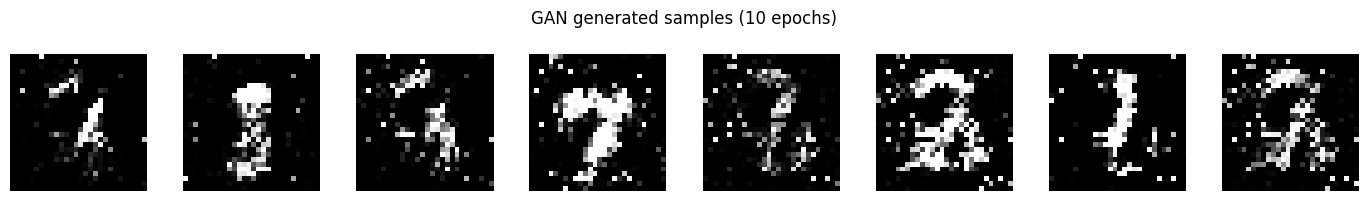

GAN key concepts:
  Generator:      maps noise z → image — never sees real data directly
  Discriminator:  binary classifier, real vs fake
  Adversarial:    G improves by fooling D; D improves by catching G
  Equilibrium:    G loss ≈ D loss ≈ log(2) ≈ 0.693 at Nash equilibrium
  Mode collapse:  G learns to produce one convincing image — major failure mode


In [ ]:
# --- GAN: sample from learned distribution ---
G.eval()
with torch.no_grad():
    z = torch.randn(8, LATENT_DIM).to(device)
    samples = G(z).view(-1, 28, 28).cpu()

fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i, ax in enumerate(axes):
    ax.imshow(samples[i], cmap='gray')
    ax.axis('off')
plt.suptitle("GAN generated samples (10 epochs)")
plt.tight_layout(); plt.show()

# Key GAN concepts summary
print("GAN key concepts:")
print("  Generator:      maps noise z → image — never sees real data directly")
print("  Discriminator:  binary classifier, real vs fake")
print("  Adversarial:    G improves by fooling D; D improves by catching G")
print("  Equilibrium:    G loss ≈ D loss ≈ log(2) ≈ 0.693 at Nash equilibrium")
print("  Mode collapse:  G learns to produce one convincing image — major failure mode")

In [ ]:
LATENT_DIM_VAE = 16

class VAE(nn.Module):
  def __init__(self):
        super().__init__()
        # Encoder: image → latent distribution parameters
        self.encoder = nn.Sequential(
            nn.Linear(IMAGE_DIM, 512), nn.ReLU(),
            nn.Linear(512, 256),       nn.ReLU(),
        )
        self.fc_mu     = nn.Linear(256, LATENT_DIM_VAE)
        self.fc_logvar = nn.Linear(256, LATENT_DIM_VAE)

         # Decoder: latent sample → image
        self.decoder = nn.Sequential(
            nn.Linear(LATENT_DIM_VAE, 256), nn.ReLU(),
            nn.Linear(256, 512),            nn.ReLU(),
            nn.Linear(512, IMAGE_DIM),      nn.Tanh()
        )

  def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

  def reparameterise(self, mu, logvar):
        # z = μ + σ·ε   where ε ~ N(0,I)
        # Reparameterisation trick: makes sampling differentiable
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

  def decode(self, z):
        return self.decoder(z)

  def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterise(mu, logvar)
        return self.decode(z), mu, logvar

# Instantiate VAE and its optimizer
vae = VAE().to(device)
opt_vae = optim.Adam(vae.parameters(), lr=1e-3)

print("VAE architecture:")
print(vae)
print(f"\nTotal parameters: {sum(p.numel() for p in vae.parameters()):,}")

VAE architecture:
VAE(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
  )
  (fc_mu): Linear(in_features=256, out_features=16, bias=True)
  (fc_logvar): Linear(in_features=256, out_features=16, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=784, bias=True)
    (5): Tanh()
  )
)

Total parameters: 1,079,600


In [ ]:
def vae_loss(recon, x, mu, logvar):
    # Reconstruction: how well the decoder recovered the input
    recon_loss = nn.functional.mse_loss(recon, x, reduction='sum')
    # KL divergence: how close the latent distribution is to N(0,I)
    # KL = -0.5 · Σ(1 + log σ² - μ² - σ²)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss, recon_loss, kl_loss


  Epoch  1/10  total=154.53  recon=143.90  kl=10.62
  Epoch  2/10  total=95.84  recon=79.20  kl=16.65
  Epoch  3/10  total=85.55  recon=67.85  kl=17.69
  Epoch  4/10  total=80.34  recon=61.81  kl=18.53
  Epoch  5/10  total=76.96  recon=57.88  kl=19.09
  Epoch  6/10  total=74.69  recon=55.14  kl=19.55
  Epoch  7/10  total=72.90  recon=53.08  kl=19.82
  Epoch  8/10  total=71.52  recon=51.45  kl=20.07
  Epoch  9/10  total=70.29  recon=49.99  kl=20.30
  Epoch 10/10  total=69.23  recon=48.67  kl=20.56


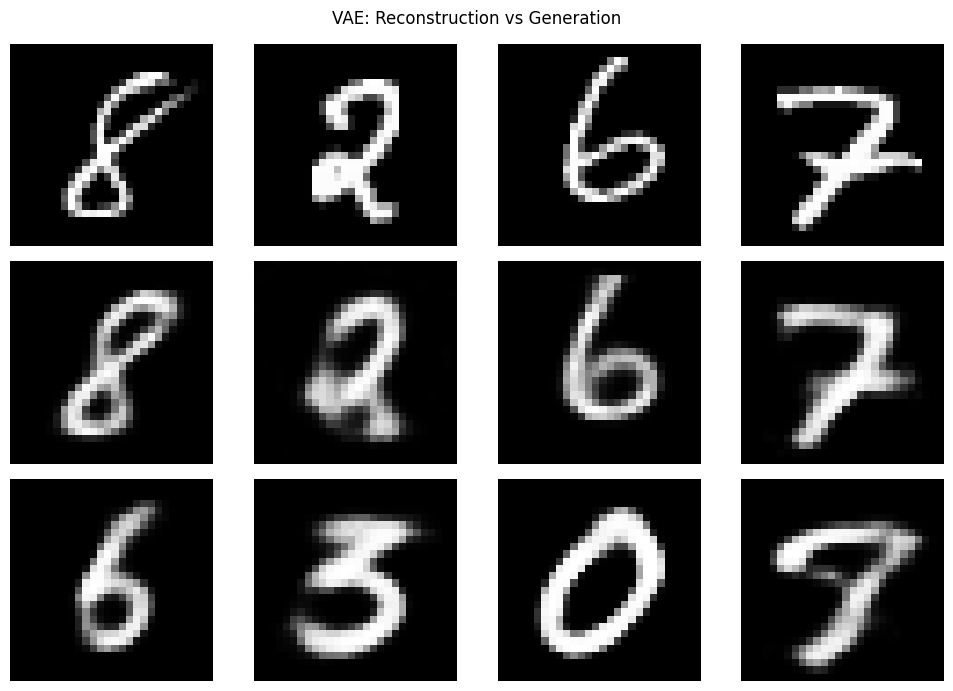

In [ ]:
# --- VAE training ---
vae_losses, recon_losses, kl_losses = [], [], []
EPOCHS_VAE = 10

for epoch in range(EPOCHS_VAE):
    total, recon_t, kl_t = 0.0, 0.0, 0.0
    for imgs, _ in loader:
        imgs = imgs.view(-1, IMAGE_DIM).to(device)
        opt_vae.zero_grad()
        recon, mu, logvar = vae(imgs)
        loss, recon_l, kl_l = vae_loss(recon, imgs, mu, logvar)
        loss.backward()
        opt_vae.step()
        total += loss.item(); recon_t += recon_l.item(); kl_t += kl_l.item()

    n = len(loader.dataset)
    vae_losses.append(total/n); recon_losses.append(recon_t/n); kl_losses.append(kl_t/n)
    print(f"  Epoch {epoch+1:>2}/{EPOCHS_VAE}  total={vae_losses[-1]:.2f}  recon={recon_losses[-1]:.2f}  kl={kl_losses[-1]:.2f}")

# --- Reconstruct and sample ---
vae.eval()
with torch.no_grad():
    test_imgs = next(iter(loader))[0][:4].view(-1, IMAGE_DIM).to(device)
    recon_imgs, _, _ = vae(test_imgs)
    z_sample = torch.randn(4, LATENT_DIM_VAE).to(device)
    generated = vae.decode(z_sample)

fig, axes = plt.subplots(3, 4, figsize=(10, 7))
for i in range(4):
    axes[0,i].imshow(test_imgs[i].cpu().view(28,28), cmap='gray'); axes[0,i].axis('off')
    axes[1,i].imshow(recon_imgs[i].cpu().view(28,28), cmap='gray'); axes[1,i].axis('off')
    axes[2,i].imshow(generated[i].cpu().view(28,28), cmap='gray'); axes[2,i].axis('off')
axes[0,0].set_ylabel("Original", fontsize=10)
axes[1,0].set_ylabel("Reconstructed", fontsize=10)
axes[2,0].set_ylabel("Generated\n(z ~ N(0,I))", fontsize=10)
plt.suptitle("VAE: Reconstruction vs Generation")
plt.tight_layout(); plt.show()